In [ ]:
# necessary path specification so that the Jupyter Notebook can acces the utils and other folders 

from pathlib import Path
import sys

folder = Path.cwd().parent
sys.path.insert(0, str(folder))

c:\Users\johan\Documents\Biologie Master\Projektlabor Cell Cycle Elongation\Master_Thesis_Code\utils\visualization.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), fancybox = True, ncol = 5)


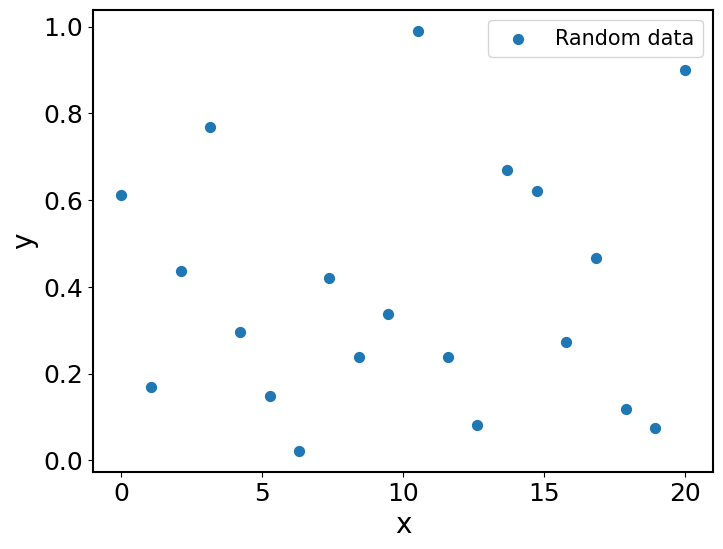

In [4]:
'''PlotDigitizer Evaluation

Create random data sets to test PlotDigitizer data point extraction with. 
1) 2x20 data points are created and plotted in a scatter plot, respectively (2 different marker types)
2) numerical data obtained by extracting from these plots is compared to the true values to assess 
   graphical data extraction reliability. 
'''



import matplotlib.pyplot as plt
import numpy as np
from numpy import random
import utils.visualization

np.random.seed(111)

x = np.linspace(0, 20, 20)
y = random.rand(20)    # create 20 random data points 


utils.visualization.plot_layout()
plt.scatter(x, y, s = 50, label = 'Random data')
plt.xlabel('x', fontsize = utils.visualization.LABEL_FONTSIZE)
plt.ylabel('y', fontsize = utils.visualization.LABEL_FONTSIZE)
plt.legend(fontsize = utils.visualization.LEGEND_FONTSIZE)

[[1.         0.99999671]
 [0.99999671 1.        ]]
PearsonRResult(statistic=np.float64(0.9999967139821281), pvalue=np.float64(4.241985174297209e-48))
1.0008705977508374 0.000908497028016042 4.241985173007435e-48 0.9999967139821281


c:\Users\johan\Documents\Biologie Master\Projektlabor Cell Cycle Elongation\Master_Thesis_Code\utils\visualization.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), fancybox = True, ncol = 5)


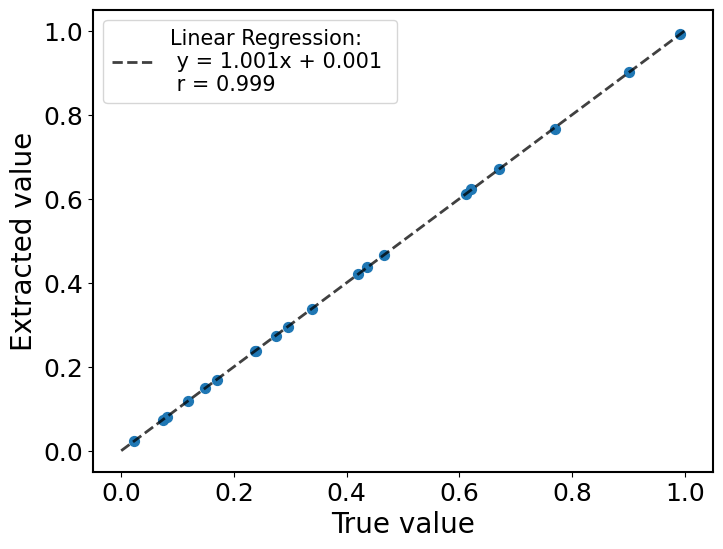

In [5]:
# Evaluate data extraction for data presented as points 

import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from utils.visualization import plot_layout

extracted_data = pd.read_csv('extracted_data_20_random_points.csv')        # load data set of extracted data points (using PlotDigitizer)

extracted_y = sorted(extracted_data[' y'])
true_y = sorted(y) 

# calculate correlation between true and extracted values using different correlation measurements 
corr = np.corrcoef(true_y, extracted_y)         
print(corr)

corr2 = scipy.stats.pearsonr(true_y, extracted_y)       
print(corr2)


lincorr = scipy.stats.linregress(true_y, extracted_y)           # calculate linear regression to obtain estimated k and d values 
k = lincorr.slope
d = lincorr.intercept
p = lincorr.pvalue
r = lincorr.rvalue

print(k, d, p, r)

# define linear function using the values for k and d estimated by the linear regression model 
def func(x):
    y = k*x + d
    return y


x_vals = np.linspace(0, 1)
fity = func(x_vals)            # linear regression simulated values  

# show linear regression estimate 
plot_layout()
plt.scatter(true_y, extracted_y, s = 50)
plt.plot(x_vals, fity, linestyle = '--', color = 'black', linewidth = 2, alpha = 0.75, label = 'Linear Regression: \n y = 1.001x + 0.001 \n r = 0.999')
plt.xlabel(r'True value', fontsize = utils.visualization.LABEL_FONTSIZE)
plt.ylabel('Extracted value', fontsize = utils.visualization.LABEL_FONTSIZE)
plt.legend(fontsize = utils.visualization.LEGEND_FONTSIZE)

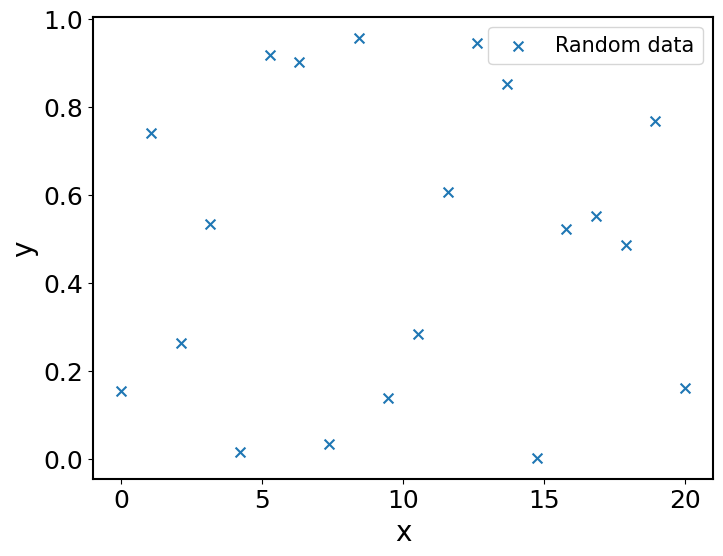

In [6]:
# Create evaluation dataset for data presented as points

import matplotlib.pyplot as plt
import numpy as np
from numpy import random
from utils.visualization import plot_layout
import utils.visualization

np.random.seed(12)

x = np.linspace(0, 20, 20)
y2 = random.rand(20)


plot_layout()
plt.scatter(x, y2, s = 50, label = 'Random data', marker = 'x')
plt.xlabel('x', fontsize = utils.visualization.LABEL_FONTSIZE)
plt.ylabel('y', fontsize = utils.visualization.LABEL_FONTSIZE)
plt.legend(fontsize = utils.visualization.LEGEND_FONTSIZE)

[[1.         0.99999662]
 [0.99999662 1.        ]]
PearsonRResult(statistic=np.float64(0.9999966158915146), pvalue=np.float64(5.527620193974633e-48))
1.0005796432972436 0.00020632317369456699 5.527620192342663e-48 0.9999966158915147


C:\Users\johan\Documents\Biologie Master\Projektlabor Cell Cycle Elongation\Master Thesis\utils\visualization.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), fancybox = True, ncol = 5)


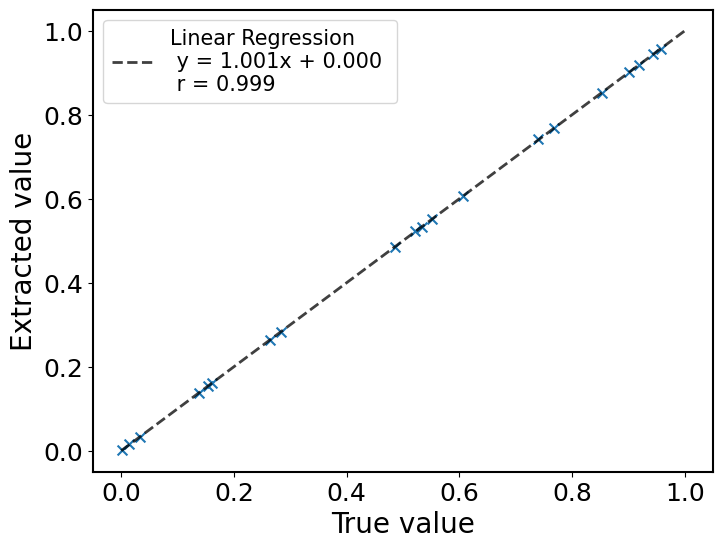

In [6]:

import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from utils.visualization import plot_layout

extracted_data2 = pd.read_csv('extracted_data_20_random_x_markers.csv')

extracted_y2 = sorted(extracted_data2[' y'])
true_y2 = sorted(y2) 


corr = np.corrcoef(true_y2, extracted_y2)
print(corr)

corr2 = scipy.stats.pearsonr(true_y2, extracted_y2)
print(corr2)


lincorr = scipy.stats.linregress(true_y2, extracted_y2)
k = lincorr.slope
d = lincorr.intercept
p = lincorr.pvalue
r = lincorr.rvalue

print(k, d, p, r)


def func(x):
    y = k*x + d
    return y

x_vals = np.linspace(0, 1)
fity2 = func(x_vals)

plot_layout(figsize = (6, 4))
plt.scatter(true_y2, extracted_y2, s = 50, marker = 'x')
plt.plot(x_vals, fity2, linestyle = '--', color = 'black', linewidth = 2, alpha = 0.75, label = 'Linear Regression \n y = 1.001x + 0.000 \n r = 0.999')
plt.xlabel(r'True value', fontsize = utils.visualization.LABEL_FONTSIZE)
plt.ylabel('Extracted value', fontsize = utils.visualization.LABEL_FONTSIZE)
plt.legend(fontsize = utils.visualization.LEGEND_FONTSIZE)


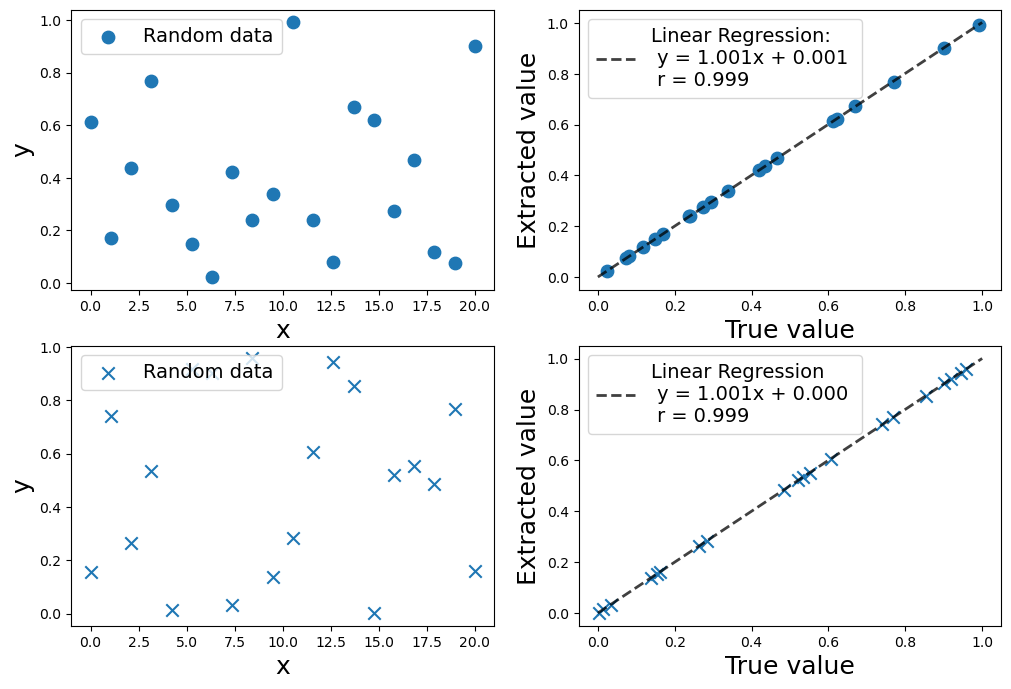

In [ ]:
# Put everything in one plot for easy comparability

label_fontsize = 18
legend_fontsize = 14
marker_size = 80

plt.figure(figsize=(12,8))

plt.subplot(2, 2, 1)
plt.scatter(x, y, s = marker_size, label = 'Random data')
plt.xlabel('x', fontsize = label_fontsize)
plt.ylabel('y', fontsize = label_fontsize)
plt.legend(fontsize = legend_fontsize, loc = 'upper left')



plt.subplot(2, 2, 2)
plt.scatter(true_y, extracted_y, s = marker_size)
plt.plot(x_vals, fity, linestyle = '--', color = 'black', linewidth = 2, alpha = 0.75, label = 'Linear Regression: \n y = 1.001x + 0.001 \n r = 0.999')
plt.xlabel(r'True value', fontsize = label_fontsize)
plt.ylabel('Extracted value', fontsize = label_fontsize)
plt.legend(fontsize = legend_fontsize)


plt.subplot(2, 2, 3)
plt.scatter(x, y2, s = marker_size, label = 'Random data', marker = 'x')
plt.xlabel('x', fontsize = label_fontsize)
plt.ylabel('y', fontsize = label_fontsize)
plt.legend(fontsize = legend_fontsize, loc = 'upper left')

plt.subplot(2, 2, 4)
plt.scatter(true_y2, extracted_y2, s = marker_size, marker = 'x')
plt.plot(x_vals, fity2, linestyle = '--', color = 'black', linewidth = 2, alpha = 0.75, label = 'Linear Regression \n y = 1.001x + 0.000 \n r = 0.999')
plt.xlabel(r'True value', fontsize = label_fontsize)
plt.ylabel('Extracted value', fontsize = label_fontsize)
plt.legend(fontsize = legend_fontsize)

plt.savefig('EvaluationPlotDigitizer.png', dpi = 1200)
